In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv('data/placement.csv')
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [3]:
type(df)

pandas.core.frame.DataFrame

In [4]:
type(df.iq) #column is series

pandas.core.series.Series

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [6]:
df.shape

(100, 4)

In [7]:
df.columns

Index(['Unnamed: 0', 'cgpa', 'iq', 'placement'], dtype='object')

In [8]:
df.drop(columns = ['Unnamed: 0'],inplace = True)

In [9]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


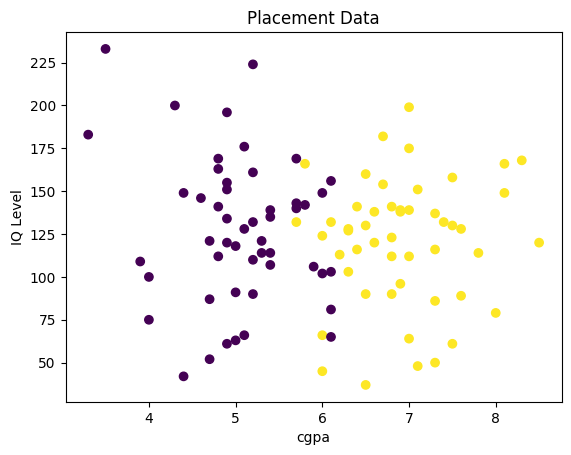

In [10]:
plt.title("Placement Data")
plt.xlabel("cgpa")
plt.ylabel("IQ Level")
plt.scatter(x= df['cgpa'],y = df['iq'], c=df['placement']) 
plt.savefig('placement scatter plot')
plt.show()

In [11]:
df['cgpa'].nunique()

39

In [12]:
df['cgpa'].unique()

array([6.8, 5.9, 5.3, 7.4, 5.8, 7.1, 5.7, 5. , 6.1, 5.1, 6. , 6.9, 5.4,
       6.4, 5.2, 3.3, 4. , 6.6, 4.9, 4.7, 7. , 7.6, 3.9, 4.8, 8.1, 6.5,
       4.6, 7.5, 3.5, 8.3, 7.8, 8. , 7.3, 6.3, 8.5, 6.7, 4.4, 4.3, 6.2])

In [13]:
df['cgpa'].value_counts()

cgpa
4.9    6
5.2    5
6.1    5
7.0    5
6.0    5
6.8    4
7.3    4
6.5    4
5.7    4
4.8    4
5.4    4
6.3    3
7.5    3
4.7    3
5.0    3
6.9    3
5.1    3
6.4    2
5.3    2
5.8    2
6.7    2
7.1    2
8.1    2
4.4    2
7.6    2
6.6    2
4.0    2
8.0    1
4.3    1
8.5    1
7.4    1
4.6    1
7.8    1
8.3    1
3.5    1
3.3    1
3.9    1
5.9    1
6.2    1
Name: count, dtype: int64

In [14]:
df['iq'].std()

39.94419845107659

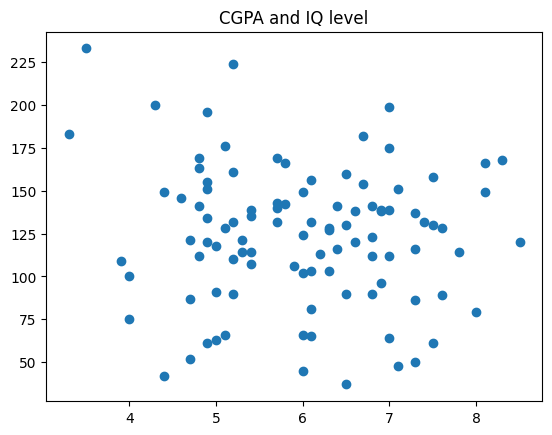

In [15]:
plt.title("CGPA and IQ level")
plt.scatter(df['cgpa'],df['iq'])
plt.show()

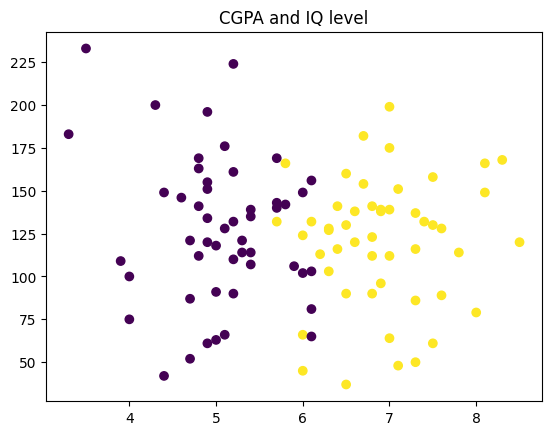

In [16]:
plt.title("CGPA and IQ level")
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])
plt.show()

In [17]:
df.isnull().sum()

cgpa         0
iq           0
placement    0
dtype: int64

In [18]:
df.placement.value_counts()
# placement have 2 categories
#upsampling = you increase the data value
# downsampling = you try to make it equal, by bringing it down 
#here, no need to do up or down sampling since the placements are equal

placement
1    50
0    50
Name: count, dtype: int64

In [19]:
X=df.drop(columns=['placement'])
y= df['placement']

In [20]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [21]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [22]:
# train train split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=40)

In [23]:
X_train

,cgpa,iq
72,7.3,116.0
66,6.9,96.0
69,8.5,120.0
67,5.0,118.0
26,7.0,199.0
...,...,...
56,6.1,65.0
37,8.1,149.0
7,5.0,63.0
91,7.5,158.0


In [24]:
X_test

,cgpa,iq
79,6.5,90.0
75,4.8,169.0
63,6.3,128.0
15,5.1,176.0
38,6.5,160.0
11,6.9,138.0
40,4.9,134.0
45,6.0,66.0
39,4.6,146.0
62,6.0,102.0


In [25]:
y_train

72    1
66    1
69    1
67    0
26    1
     ..
56    0
37    1
7     0
91    1
70    1
Name: placement, Length: 80, dtype: int64

In [26]:
y_test

79    1
75    0
63    1
15    0
38    1
11    1
40    0
45    1
39    0
62    0
86    0
4     0
47    0
27    1
81    0
17    0
82    1
33    0
9     0
92    0
Name: placement, dtype: int64

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
model = LogisticRegression()

In [29]:
model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [31]:
y_pred = model.predict(X_test)

In [32]:
pd.DataFrame({'y_test': y_test,'y_pred': y_pred})

,y_test,y_pred
79,1,1
75,0,0
63,1,1
15,0,0
38,1,1
11,1,1
40,0,0
45,1,0
39,0,0
62,0,0


In [33]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score, f1_score, classification_report

In [34]:
print("Accuracy Score:", accuracy_score(y_test,y_pred))

Accuracy Score: 0.9


In [35]:
print("Confusion Matrix: \n", confusion_matrix(y_test,y_pred))

Confusion Matrix: 
 [[12  1]
 [ 1  6]]


In [36]:
print("Classification Report: \n" , classification_report(y_test,y_pred))

Classification Report: 
               precision    recall  f1-score   support

           0       0.92      0.92      0.92        13
           1       0.86      0.86      0.86         7

    accuracy                           0.90        20
   macro avg       0.89      0.89      0.89        20
weighted avg       0.90      0.90      0.90        20



In [37]:
from sklearn.preprocessing import StandardScaler
sclarer = StandardScaler()
X_train=sclarer.fit_transform(X_train)
X_train

array([[ 1.01957542e+00, -1.75050227e-01],
       [ 6.80070598e-01, -6.73413861e-01],
       [ 2.03808989e+00, -7.53774997e-02],
       [-9.32577310e-01, -1.25213863e-01],
       [ 7.64946804e-01,  1.89315886e+00],
       [-1.78133937e+00, -1.19669568e+00],
       [ 1.01957542e+00, -1.81965022e+00],
       [-6.77948693e-01, -5.04593180e-02],
       [-1.01745352e+00,  7.96758861e-01],
       [-1.01745352e+00,  1.81840431e+00],
       [ 4.25441981e-01, -7.53774997e-02],
       [ 7.64946804e-01,  3.98067953e-01],
       [-1.10232972e+00,  4.47904317e-01],
       [ 5.95194392e-01, -6.22954543e-04],
       [ 2.55689570e-01,  4.47904317e-01],
       [-8.38152531e-02, -1.94424113e+00],
       [-3.38443870e-01,  4.22986135e-01],
       [ 8.49823009e-01,  6.97086134e-01],
       [ 4.25441981e-01,  3.73149771e-01],
       [-3.38443870e-01,  4.97740680e-01],
       [ 1.01957542e+00,  3.48231590e-01],
       [ 1.01957542e+00, -9.22595679e-01],
       [-9.32577310e-01, -7.98004770e-01],
       [ 7.

In [38]:
X_test = sclarer.transform(X_test)

In [39]:
X_test

array([[ 0.34056578, -0.82292295],
       [-1.10232972,  1.14561341],
       [ 0.17081336,  0.12396795],
       [-0.8477011 ,  1.32004068],
       [ 0.34056578,  0.92134977],
       [ 0.6800706 ,  0.37314977],
       [-1.01745352,  0.27347704],
       [-0.08381525, -1.42095931],
       [-1.27208213,  0.57249523],
       [-0.08381525, -0.52390477],
       [-0.8477011 ,  0.12396795],
       [-0.25356766,  0.4728225 ],
       [-0.7628249 ,  0.94626795],
       [-0.08381525,  0.02429523],
       [-0.59307249, -0.39931386],
       [-2.37547281,  1.49446795],
       [ 0.34056578, -2.14358658],
       [-0.08381525,  0.64724977],
       [-0.8477011 , -1.42095931],
       [-0.7628249 , -0.32455932]])

In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
clf = LogisticRegression()
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [42]:
y_pred = clf.predict(X_test)
y_pred

array([1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0])

In [43]:
pd.DataFrame({'y_test':y_test,'y_predict':y_pred})

,y_test,y_predict
79,1,1
75,0,0
63,1,1
15,0,0
38,1,1
11,1,1
40,0,0
45,1,0
39,0,0
62,0,1


In [44]:
df['placement'].value_counts()

placement
1    50
0    50
Name: count, dtype: int64

In [45]:
print("Accuracy Score:",accuracy_score(y_test,y_pred))
print("Precision Score:",precision_score(y_test,y_pred))
print("Recall Score:",recall_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))

Accuracy Score: 0.85
Precision Score: 0.75
Recall Score: 0.8571428571428571
F1 Score: 0.8


In [46]:
print("Confusion Matrix:",confusion_matrix(y_test,y_pred))
print("Classification Report:",classification_report(y_test,y_pred))

Confusion Matrix: [[11  2]
 [ 1  6]]
Classification Report:               precision    recall  f1-score   support

           0       0.92      0.85      0.88        13
           1       0.75      0.86      0.80         7

    accuracy                           0.85        20
   macro avg       0.83      0.85      0.84        20
weighted avg       0.86      0.85      0.85        20



In [47]:
import seaborn as sns

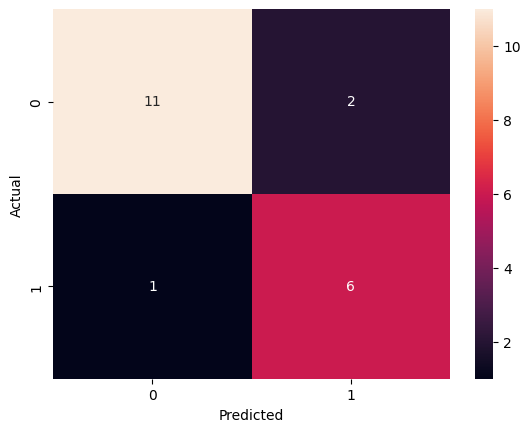

In [48]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Note: you may need to restart the kernel to use updated packages.


<Axes: >

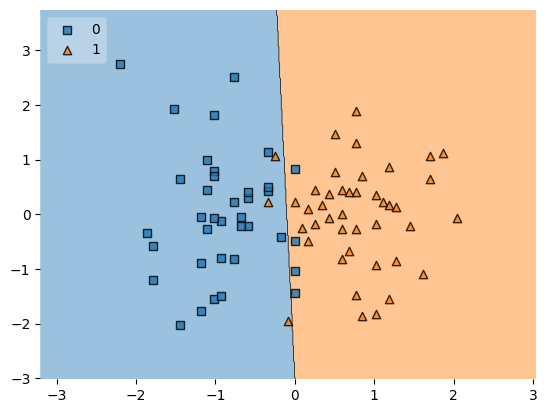

In [49]:
%pip install mlxtend
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)


<Axes: >

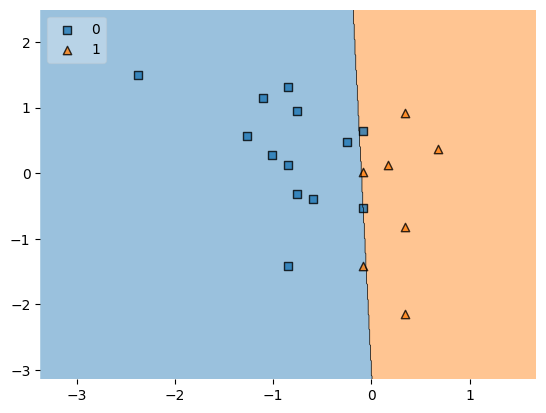

In [50]:
plot_decision_regions(X_test, y_test.values, clf=clf, legend=2)


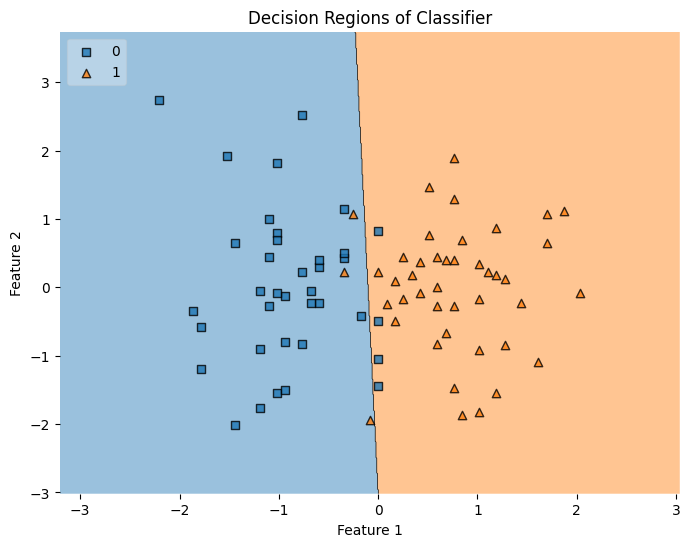

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Regions of Classifier")
plt.show()
